# Initial imports and constants 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib
import pandas as pd 
import pickle
import batman
import dill

In [2]:
TESS_offset = 2457000


# Load transit times 

In [3]:
file = 'data_1339/toi_1339_bls_data.pkl'
with open(file, 'rb') as f:
    data = pickle.load(f)

time = data['time']
flux = data['flux']
flux_err = data['flux_err']

In [4]:
### Read results
d = pd.read_csv("data_1339/toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

print(d)

     Planet_num  Index           Tc    Tc_err
0             1      0  1715.354632  0.001001
1             2      0  1726.054868  0.003165
2             1      2  1733.115272  0.004004
3             1      3  1741.996592  0.001416
4             3      0  1743.553289  0.001416
..          ...    ...          ...       ...
106           1    216  3633.506755  0.001416
107           2     67  3640.931350  0.002238
108           1    217  3642.384072  0.001416
109           1    219  3660.144712  0.001416
110           3     50  3661.127242  0.002238

[111 rows x 4 columns]


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_39831/1989409391.py:2: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("data_1339/toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [5]:
tc_2 = np.array(d.Tc[d.Planet_num==2])
tc_3 = np.array(d.Tc[d.Planet_num==3])
# print(tc_b)

In [6]:
### stellar params
q1 = 0.304
q2 = 0.40

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(u1)
print(u2)

rho_star = 1.37 # [g/cm^3]

0.44108956006688715
0.11027239001672175


In [7]:
per_2=  28.5805 #28.579743
rp_2= 0.0306 #0.03118
b_2=  0.63 #0.630


In [8]:
per_3=  38.3525 #38.353037
rp_3=  0.0302 #0.02916
b_3=  0.48 #0.440


In [9]:
dur_2_guess = 4.5 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 
dur_3_guess = 5.5 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


# Calculate nominal duration

In [10]:
from astropy.constants import G
from astropy import units as u
G_new_units = G.to(u.cm**3 / (u.g * u.day**2))

G_const = G_new_units.value

In [11]:
def T_nominal(P, rp_rstar, rho_star):
    from astropy.constants import G
    from astropy import units as u
    G_new_units = G.to(u.cm**3 / (u.g * u.day**2))
    G_const = G_new_units.value
    term1 = P / np.pi
    term2_num = (1 + rp_rstar)**2
    term2_den = ((G_const*(P**2)*rho_star)/(3*np.pi))**(2./3.)
    term2 = np.arcsin(np.sqrt(term2_num / term2_den))
    T = term1 * term2
    return T


# Find constraints 

In [12]:
# predicted duration ratio 
# file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'
# file_name = 'mcmc_runs/1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5.pkl'
file_name = 'mcmc_runs/1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5_infl_err6.pkl'


# file_name = '1339_jnkep_fit_1339-1000burn-2000step.pkl'
# file_name = '1339_jnkep_fit_1339-100burn-200step.pkl'
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [13]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.42      0.09      0.44      0.28      0.52     43.49      1.11
 ecosw_scaled[1]      0.43      0.08      0.46      0.31      0.52     43.92      1.11
 esinw_scaled[0]      0.48      0.07      0.50      0.35      0.57    207.78      1.05
 esinw_scaled[1]      0.48      0.06      0.50      0.38      0.56    206.88      1.05
period_scaled[0]      0.50      0.00      0.50      0.50      0.50     48.13      1.10
period_scaled[1]      0.50      0.00      0.50      0.50      0.50    281.11      1.02
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.03    143.77      1.06
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.02     76.66      1.08
   tic_scaled[0]      0.48      0.01      0.48      0.47      0.49     32.09      1.14
   tic_scaled[1]      0.52      0.02      0.52      0.48      0.55    195.05      1.04

Number of divergences: 4


In [14]:
posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})

{'ecc': (8, 1000, 2), 'ecosw': (8, 1000, 2), 'ecosw_scaled': (8, 1000, 2), 'ediff': (8, 1000), 'esinw': (8, 1000, 2), 'esinw_scaled': (8, 1000, 2), 'period': (8, 1000, 2), 'period_scaled': (8, 1000, 2), 'pmass': (8, 1000, 2), 'pmass_scaled': (8, 1000, 2), 'tcmodel': (8, 1000, 39), 'tic': (8, 1000, 2), 'tic_scaled': (8, 1000, 2)}


In [15]:
good_chain_idxs = [0,1,2,3,4,5,6,7]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples_flat = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}


In [16]:
### posterior samples 
ecosw_2_jnkep = samples_flat["ecosw"][:, 0]
esinw_2_jnkep = samples_flat["esinw"][:, 0]
Per_2 = samples_flat["period"][:,0] # [days]
Tc_2 = samples_flat["tic"][:,0] # [days]
pmass_2 = samples_flat["pmass"][:, 0] # [solar mass]

ecosw_3_jnkep = samples_flat["ecosw"][:, 1]
esinw_3_jnkep = samples_flat["esinw"][:, 1]
Per_3 = samples_flat["period"][:,1] # [days]
Tc_3 = samples_flat["tic"][:,1] # [days]
pmass_3 = samples_flat["pmass"][:, 1] # [solar mass]

### convert planet mass from solar to earth masses 
import astropy.constants as u
convert = (u.M_sun / u.M_earth).value
pmass_earth_2 = pmass_2 * convert
pmass_earth_3 = pmass_3 * convert


# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_2 = np.sqrt(ecosw_2_jnkep**2 + esinw_2_jnkep**2)
omega_rad_2 = np.arctan2(esinw_2_jnkep, ecosw_2_jnkep)
omega_deg_2 = np.rad2deg(omega_rad_2)

# Compute eccentricity and omega (in radians and degrees) for each sample
ecc_3 = np.sqrt(ecosw_3_jnkep**2 + esinw_3_jnkep**2)
omega_rad_3 = np.arctan2(esinw_3_jnkep, ecosw_3_jnkep)
omega_deg_3 = np.rad2deg(omega_rad_3)


In [17]:
# samples: P, rp, b, e, w

In [18]:
# compute physical stellar density for each sample from {P, rp, b, e, w} samples 
def rho_sample(P, rp, b, T14, e, w):
    from astropy.constants import G
    from astropy import units as u
    G_new_units = G.to(u.cm**3 / (u.g * u.day**2))
    G_const = G_new_units.value

    term1 = (3*np.pi) / (G_const*P**2)
    term2_num = (1 + rp)**2 - b**2
    sine_num = T14 * np.pi * (1 + e*np.sin(w))
    sine_den = P*np.sqrt(1-e**2)
    sine_term = sine_num / sine_den
    term2_den = (np.sin(sine_term))**2
    term2_frac = term2_num / term2_den
    term2 = (term2_frac + b**2)**(3./2.)
    rho = term1 * term2
    return rho 
    


# log-likelyhood of each set of physical stellar density and random draw of stellar density from Gaia
def log_like(rho_samp, rho_gaia, rho_gaia_err):
    term_num = rho_samp - rho_gaia
    term_den = rho_gaia_err
    term = term_num / term_den
    log_lk = -(1./2.)*(term)**2
    return log_lk

def weights_(log_like):
    w = np.exp(log_like)
    w /= np.sum(w)
    return w

# approximate duration ratio

In [19]:
rng = np.random.default_rng(42)
N = len(Per_2)
N=2000000

In [20]:
### use stellar density from Lubin
rho_star = 1.37 #[g/cm^3]
rho_star_err = 0.11 #/10

In [21]:
### create posteriors from Lubin 2022
### planet 2
P_2 = 28.5805
P_2_err = 0.0002 #/10
P_2_samples = rng.normal(P_2, P_2_err, N)


T14_2 = 4.5 * 0.0416667
T14_2_err = (0.2 * 0.0416667) #/ 10
T14_2_samples = rng.normal(T14_2, T14_2_err, N)
T14_2_samples = np.clip(T14_2_samples, 1e-9, None)  # days

b_2 = 0.63
b_2_err = 0.02 #/10
b_2_samples = rng.normal(b_2, b_2_err, N)
b_2_samples = np.clip(b_2_samples, 0.0, 0.999999)

rp_2 = 0.0306
rp_2_err = 0.0007 #/ 10
rp_2_samples = rng.normal(rp_2, rp_2_err, N)
rp_2_samples = np.clip(rp_2_samples, 1e-9, None)

e_2_samples = rng.uniform(0.0, 1.0, N)
omega_2_samples = rng.uniform(0.0, 2*np.pi, N)


### planet 3
P_3 = 38.3525
P_3_err = 0.0003 #/10
P_3_samples = rng.normal(P_3, P_3_err, N)

T14_3 = 5.5 * 0.0416667
T14_3_err =(0.30 * 0.0416667) #/ 10
T14_3_samples = rng.normal(T14_3, T14_3_err, N)
T14_3_samples = np.clip(T14_3_samples, 1e-9, None)  # days


b_3 = 0.48
b_3_err = 0.04 #/ 10
b_3_samples = rng.normal(b_3, b_3_err, N)
b_3_samples = np.clip(b_3_samples, 0.0, 0.999999)

rp_3 = 0.0302
rp_3_err = 0.0007 #/ 10
rp_3_samples = rng.normal(rp_3, rp_3_err, N)
rp_3_samples = np.clip(rp_3_samples, 1e-9, None)

e_3_samples = rng.uniform(0.0, 1.0, N)
omega_3_samples = rng.uniform(0.0, 2*np.pi, N)



In [22]:
def stratified_resample(N, weights, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    positions = (rng.random(N) + np.arange(N)) / N
    cumsum = np.cumsum(weights)
    return np.searchsorted(cumsum, positions)

## Planet 2

In [23]:
# rho_samp_2 = rho_sample(Per_2, rp_2_samples, b_2_samples, T14_2_samples, e_2_samples, omega_2_samples)
rho_samp_2 = rho_sample(P_2_samples, rp_2_samples, b_2_samples, T14_2_samples, e_2_samples, omega_2_samples)

log_likelihood_2 = log_like(rho_samp_2, rho_star, rho_star_err)
weights_2 = weights_(log_likelihood_2)

In [24]:
idx_2 = stratified_resample(N, weights_2, rng)
post_Per_2 = P_2_samples[idx_2]
post_T14_2 = T14_2_samples[idx_2]
post_rp_2 = rp_2_samples[idx_2]
post_b_2 = b_2_samples[idx_2]
post_e_2 = e_2_samples[idx_2]
post_omega_2 = omega_2_samples[idx_2] % (2*np.pi)
post_rho_2 = rho_samp_2[idx_2]

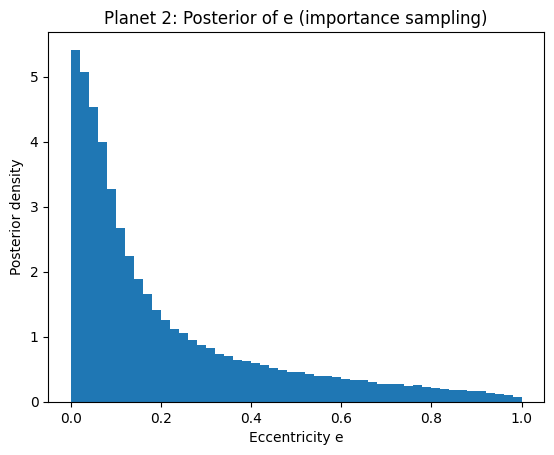

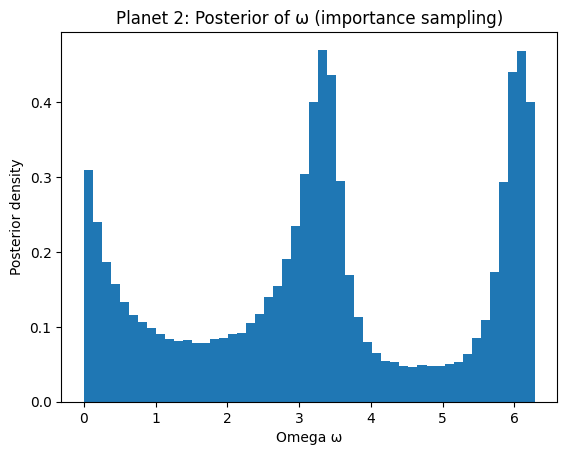

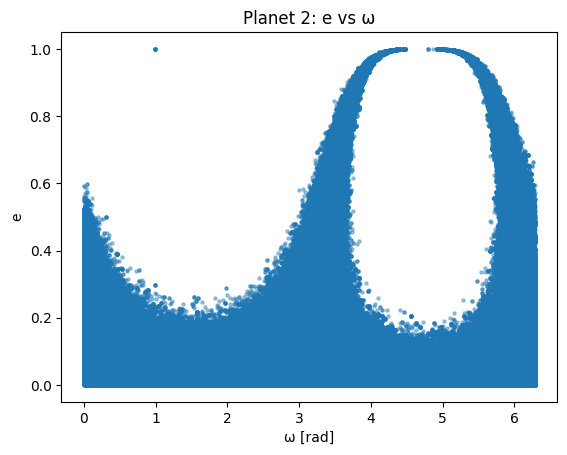

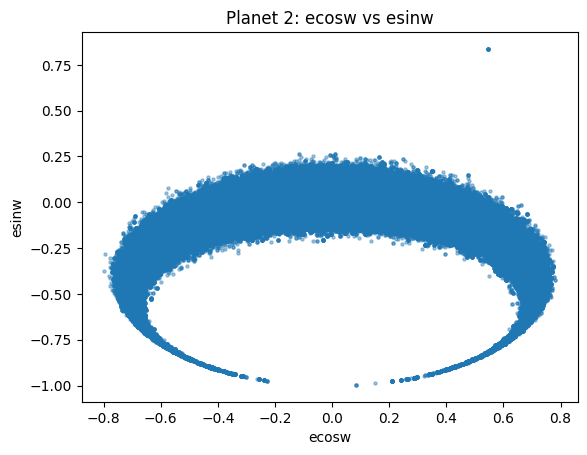

In [25]:
# Quick plots
plt.hist(post_e_2, bins=50, density=True)
plt.xlabel("Eccentricity e")
plt.ylabel("Posterior density")
plt.title("Planet 2: Posterior of e (importance sampling)")
plt.show()

plt.hist(post_omega_2, bins=50, density=True)
plt.xlabel("Omega ω")
plt.ylabel("Posterior density")
plt.title("Planet 2: Posterior of ω (importance sampling)")
plt.show()

plt.scatter(post_omega_2, post_e_2, s=5, alpha=0.4)
plt.xlabel("ω [rad]")
plt.ylabel("e")
plt.title('Planet 2: e vs ω')
plt.show()

esinw_2 = post_e_2 * np.sin(post_omega_2)
ecosw_2 = post_e_2 * np.cos(post_omega_2)
plt.scatter(ecosw_2, esinw_2, s=5, alpha=0.4)
plt.xlabel('ecosw')
plt.ylabel('esinw')
plt.title('Planet 2: ecosw vs esinw')
plt.show()

In [26]:
T_nom_2 = T_nominal(post_Per_2, post_rp_2, post_rho_2)
# T_nom_2 = T_nominal(Per_2, rp_2_samples, rho_samp_2)

In [27]:
T14_Tnom_2 = post_T14_2 / T_nom_2
print(post_T14_2 / T_nom_2)

[0.74823945 0.74823945 0.74823945 ... 0.75358928 0.75358928 0.75358928]


Median: 0.7806463215208013
16th percentile: 0.7441676081127193
84th percentile: 0.8133267457844692


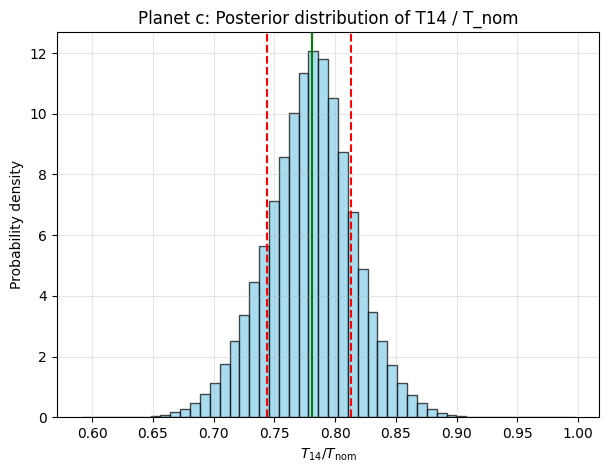

In [28]:
# Quick statistics
print("Median:", np.median(T14_Tnom_2))
print("16th percentile:", np.percentile(T14_Tnom_2, 16))
print("84th percentile:", np.percentile(T14_Tnom_2, 84))
p16_2, p84_2 = np.percentile(T14_Tnom_2, [16, 84])
median_2 = np.median(T14_Tnom_2)

# Plot histogram
plt.figure(figsize=(7,5))
plt.hist(T14_Tnom_2, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='k')
# Add vertical dashed lines
plt.axvline(p16_2, color='red', linestyle='--', label='16th percentile')
plt.axvline(p84_2, color='red', linestyle='--', label='84th percentile')
plt.axvline(median_2, color='green', linestyle='-', label='Median')

plt.xlabel(r"$T_{14} / T_\mathrm{nom}$")
plt.ylabel("Probability density")
plt.title("Planet c: Posterior distribution of T14 / T_nom")
plt.grid(alpha=0.3)
plt.show()

## Planet 3

In [29]:
rho_samp_3 = rho_sample(P_3_samples, rp_3_samples, b_3_samples, T14_3_samples, e_3_samples, omega_3_samples)
log_likelihood_3 = log_like(rho_samp_3, rho_star, rho_star_err)
weights_3 = weights_(log_likelihood_3)

In [30]:
idx_3 = stratified_resample(N, weights_3, rng)
post_Per_3 = P_3_samples[idx_3]
post_T14_3 = T14_3_samples[idx_3]
post_rp_3 = rp_3_samples[idx_3]
post_b_3 = b_3_samples[idx_3]
post_e_3 = e_3_samples[idx_3]
post_omega_3 = omega_3_samples[idx_3] 
post_rho_3 = rho_samp_3[idx_3]

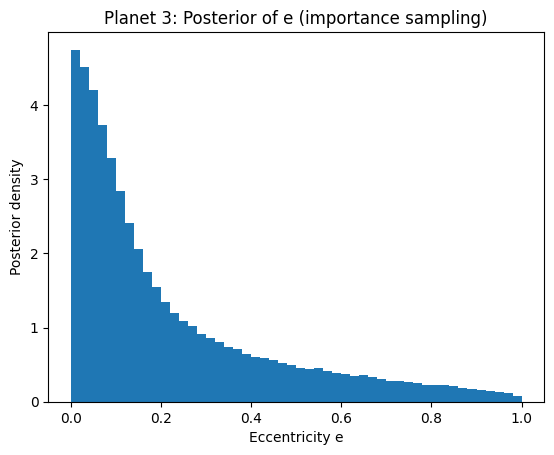

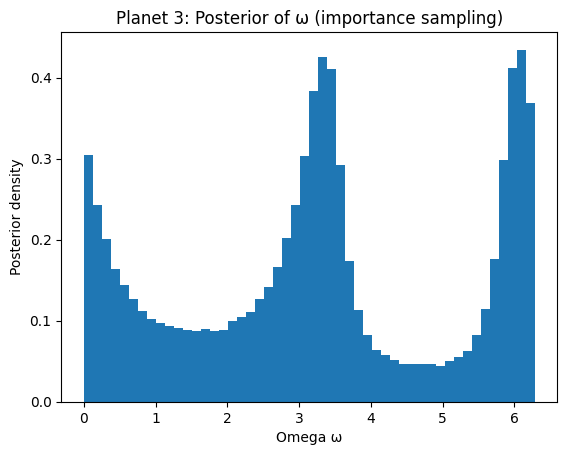

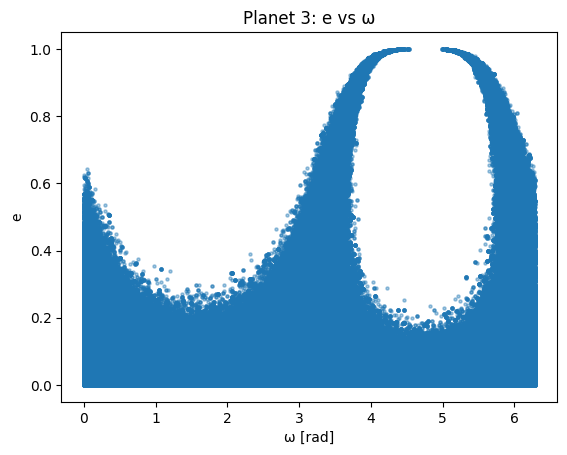

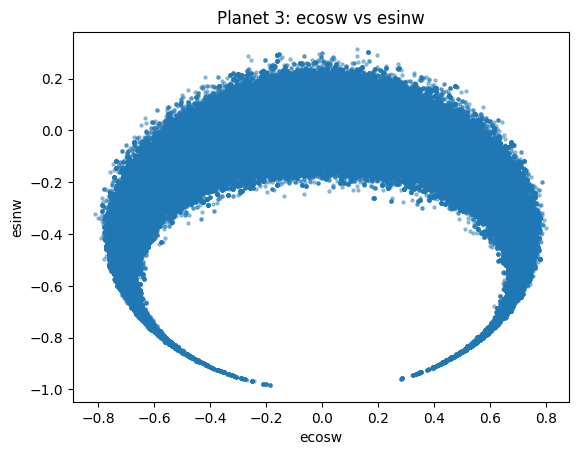

In [31]:
# Quick plots
plt.hist(post_e_3, bins=50, density=True)
plt.xlabel("Eccentricity e")
plt.ylabel("Posterior density")
plt.title("Planet 3: Posterior of e (importance sampling)")
plt.show()

plt.hist(post_omega_3, bins=50, density=True)
plt.xlabel("Omega ω")
plt.ylabel("Posterior density")
plt.title("Planet 3: Posterior of ω (importance sampling)")
plt.show()

# plt.hexbin(post_omega_2 % (2*np.pi), post_e_2, gridsize=60, bins='log')
# plt.xlabel("ω [rad]")
# plt.ylabel("e")
# plt.title("Joint posterior (e, ω)")
# plt.show()

plt.scatter(post_omega_3, post_e_3, s=5, alpha=0.4)
plt.xlabel("ω [rad]")
plt.ylabel("e")
plt.title('Planet 3: e vs ω')
plt.show()

esinw_3 = post_e_3 * np.sin(post_omega_3)
ecosw_3 = post_e_3 * np.cos(post_omega_3)
plt.scatter(ecosw_3, esinw_3, s=5, alpha=0.4)
plt.xlabel('ecosw')
plt.ylabel('esinw')
plt.title('Planet 3: ecosw vs esinw')
plt.show()

In [32]:
T_nom_3 = T_nominal(post_Per_3, post_rp_3, post_rho_3)
# T_nom_2 = T_nominal(Per_2, rp_2_samples, rho_samp_2)

In [33]:
T14_Tnom_3 = post_T14_3 / T_nom_3
print(post_T14_3 / T_nom_3)

[0.89161458 0.89161458 0.89161458 ... 0.90809063 0.90809063 0.90809063]


Median: 0.8671853151877689
16th percentile: 0.8193801391477741
84th percentile: 0.9095732085293253


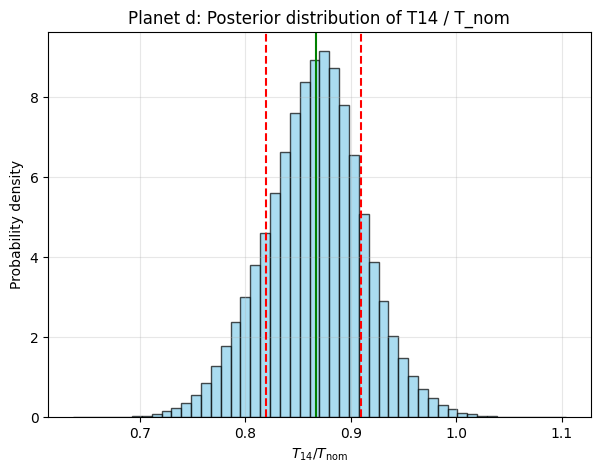

In [34]:
# Quick statistics
print("Median:", np.median(T14_Tnom_3))
print("16th percentile:", np.percentile(T14_Tnom_3, 16))
print("84th percentile:", np.percentile(T14_Tnom_3, 84))
p16_3, p84_3 = np.percentile(T14_Tnom_3, [16, 84])
median_3 = np.median(T14_Tnom_3)

# Plot histogram
plt.figure(figsize=(7,5))
plt.hist(T14_Tnom_3, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='k')
# Add vertical dashed lines
plt.axvline(p16_3, color='red', linestyle='--', label='16th percentile')
plt.axvline(p84_3, color='red', linestyle='--', label='84th percentile')
plt.axvline(median_3, color='green', linestyle='-', label='Median')

plt.xlabel(r"$T_{14} / T_\mathrm{nom}$")
plt.ylabel("Probability density")
plt.title("Planet d: Posterior distribution of T14 / T_nom")
# plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
print(len(weights_2))
print(len(ecosw_2))

2000000
2000000


In [36]:
print("ecc2 Median:", np.median(post_e_2))
print("ecc2 16th percentile:", np.percentile(post_e_2, 16))
print("ecc2 84th percentile:", np.percentile(post_e_2, 84))
print("ecc3 Median:", np.median(post_e_3))
print("ecc3 16th percentile:", np.percentile(post_e_3, 16))
print("ecc3 84th percentile:", np.percentile(post_e_3, 84))

ecc2 Median: 0.12032789285210499
ecc2 16th percentile: 0.030015317319213697
ecc2 84th percentile: 0.43787373291591547
ecc3 Median: 0.1332718916677934
ecc3 16th percentile: 0.034254619493257144
ecc3 84th percentile: 0.45362994518777666


In [37]:
# -------------------------------
# Planet 2: filter negligible weights
# -------------------------------
mask_2 = weights_2 > (1e-1 * weights_2.max())
P_2_samples     = P_2_samples[mask_2]
T14_2_samples   = T14_2_samples[mask_2]
rp_2_samples    = rp_2_samples[mask_2]
b_2_samples     = b_2_samples[mask_2]
e_2_samples     = e_2_samples[mask_2]
omega_2_samples = omega_2_samples[mask_2]
rho_samp_2      = rho_samp_2[mask_2]
weights_2       = weights_2[mask_2]

# Resample using surviving weights
weights_2 = weights_2 / np.sum(weights_2)
idx_2 = stratified_resample(len(weights_2), weights_2, rng)

# Posterior samples
post_Per_2     = P_2_samples[idx_2]
post_T14_2     = T14_2_samples[idx_2]
post_rp_2      = rp_2_samples[idx_2]
post_b_2       = b_2_samples[idx_2]
post_e_2       = e_2_samples[idx_2]
post_omega_2   = omega_2_samples[idx_2] % (2*np.pi)
post_rho_2     = rho_samp_2[idx_2]

# Derived quantities
ecosw_2 = post_e_2 * np.cos(post_omega_2)
esinw_2 = post_e_2 * np.sin(post_omega_2)

# -------------------------------
# Planet 3: filter negligible weights
# -------------------------------
mask_3 = weights_3 > (1e-1 * weights_3.max())
P_3_samples     = P_3_samples[mask_3]
T14_3_samples   = T14_3_samples[mask_3]
rp_3_samples    = rp_3_samples[mask_3]
b_3_samples     = b_3_samples[mask_3]
e_3_samples     = e_3_samples[mask_3]
omega_3_samples = omega_3_samples[mask_3]
rho_samp_3      = rho_samp_3[mask_3]
weights_3       = weights_3[mask_3]

# Resample using surviving weights
weights_3 = weights_3 / np.sum(weights_3)
idx_3 = stratified_resample(len(weights_3), weights_3, rng)

# Posterior samples
post_Per_3     = P_3_samples[idx_3]
post_T14_3     = T14_3_samples[idx_3]
post_rp_3      = rp_3_samples[idx_3]
post_b_3       = b_3_samples[idx_3]
post_e_3       = e_3_samples[idx_3]
post_omega_3   = omega_3_samples[idx_3] % (2*np.pi)
post_rho_3     = rho_samp_3[idx_3]

# Derived quantities
ecosw_3 = post_e_3 * np.cos(post_omega_3)
esinw_3 = post_e_3 * np.sin(post_omega_3)


In [38]:
print(len(esinw_2))

287532


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


def compute_kde_contour_levels(x, y, gridsize=500, bw=0.01):
    data = np.vstack([x, y])
    n=len(data)
    d=2
    # bw = n**(-1/(d+4)) * np.std(data)
    kde = gaussian_kde(data, bw_method=bw)
    # kde = gaussian_kde(data, bw_method=0.08)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    X, Y = np.mgrid[x_min:x_max:gridsize*1j, y_min:y_max:gridsize*1j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)
    return X, Y, Z, kde

def get_sigma_contour_levels(Z):
    Z_flat = Z.flatten()
    Z_sorted = np.sort(Z_flat)[::-1]
    cumsum = np.cumsum(Z_sorted)
    cumsum /= cumsum[-1]
    levels = []
    for sigma in [0.683, 0.954]:
        idx = np.searchsorted(cumsum, sigma)
        levels.append(Z_sorted[idx])
    return sorted(levels)  # ensures ascending order

# Compute KDEs
Xb, Yb, Zb, kde_b = compute_kde_contour_levels(ecosw_2, esinw_2)
Xc, Yc, Zc, kde_c = compute_kde_contour_levels(ecosw_3, esinw_3)

Xb_jnkep, Yb_jnkep, Zb_jnkep, kde_b_jnkep = compute_kde_contour_levels(ecosw_2_jnkep, esinw_2_jnkep)
Xc_jnkep, Yc_jnkep, Zc_jnkep, kde_c_jnkep = compute_kde_contour_levels(ecosw_3_jnkep, esinw_3_jnkep)

# Get contour levels
levels_b = get_sigma_contour_levels(Zb)
levels_c = get_sigma_contour_levels(Zc)

levels_b_jnkep = get_sigma_contour_levels(Zb_jnkep)
levels_c_jnkep = get_sigma_contour_levels(Zc_jnkep)

# # Plot
# fig, ax = plt.subplots(figsize=(6, 6))

# # Filled contours for planet b (blue shades)
# ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)
# ax.contourf(Xb_jnkep, Yb_jnkep, Zb_jnkep, levels=levels_b_jnkep + [Zb_jnkep.max()], colors=['#4bcec6', '#217873'], alpha=0.5)

# # Filled contours for planet c (green shades)
# ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)
# ax.contourf(Xc_jnkep, Yc_jnkep, Zc_jnkep, levels=levels_c_jnkep + [Zc_jnkep.max()], colors=['#c64bce', '#732178'], alpha=0.5)

# ax.scatter(np.median(ecosw_2), np.median(esinw_2), c='#a6cee3', label='2 median')
# ax.scatter(np.median(ecosw_3), np.median(esinw_3), c='#b2df8a', label='3 median')
# ax.scatter(np.median(ecosw_2_jnkep), np.median(esinw_2_jnkep), c='#4bcec6', label='2 median jnkep')
# ax.scatter(np.median(ecosw_3_jnkep), np.median(esinw_3_jnkep), c='#c64bce', label='3 median jnkep')
# # ax.scatter(ecosw_2, esinw_2, c='gray', s=1, alpha=0.3, label='2 samples')
# # ax.scatter(ecosw_3, esinw_3, c='black', s=1, alpha=0.3, label='3 samples')


# # Labels and legend
# ax.set_xlabel(r"$e \cos\omega$")
# ax.set_ylabel(r"$e \sin\omega$")
# ax.set_title("2D Posterior for Planets c and d")
# blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet 2')
# red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet 3')
# cyan_patch = plt.Line2D([], [], color='#4bcec6', label='Planet 2 jnkep')
# purple_patch = plt.Line2D([], [], color='#c64bce', label='Planet 3 jnkep')
# ax.legend(handles=[blue_patch, red_patch, cyan_patch, purple_patch])

# plt.grid(True)
# # plt.xlim(-0.30,0.30)
# plt.ylim(-0.90,0.30)
# plt.tight_layout()
# plt.show()

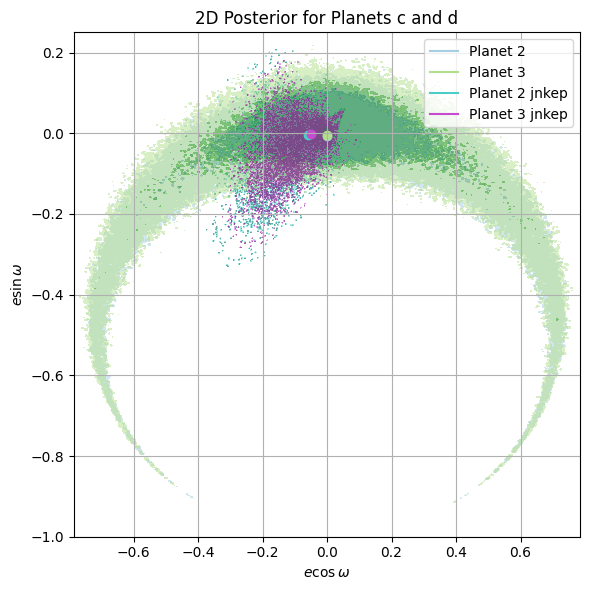

In [40]:
# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours for planet b (blue shades)
ax.contourf(Xb, Yb, Zb, levels=levels_b + [Zb.max()], colors=['#a6cee3', '#1f78b4'], alpha=0.5)
ax.contourf(Xb_jnkep, Yb_jnkep, Zb_jnkep, levels=levels_b_jnkep + [Zb_jnkep.max()], colors=['#4bcec6', '#217873'], alpha=0.5)

# Filled contours for planet c (green shades)
ax.contourf(Xc, Yc, Zc, levels=levels_c + [Zc.max()], colors=['#b2df8a', '#33a02c'], alpha=0.5)
ax.contourf(Xc_jnkep, Yc_jnkep, Zc_jnkep, levels=levels_c_jnkep + [Zc_jnkep.max()], colors=['#c64bce', '#732178'], alpha=0.5)

ax.scatter(np.median(ecosw_2), np.median(esinw_2), c='#a6cee3', label='2 median')
ax.scatter(np.median(ecosw_3), np.median(esinw_3), c='#b2df8a', label='3 median')
ax.scatter(np.median(ecosw_2_jnkep), np.median(esinw_2_jnkep), c='#4bcec6', label='2 median jnkep')
ax.scatter(np.median(ecosw_3_jnkep), np.median(esinw_3_jnkep), c='#c64bce', label='3 median jnkep')
# ax.scatter(ecosw_2, esinw_2, c='gray', s=1, alpha=0.3, label='2 samples')
# ax.scatter(ecosw_3, esinw_3, c='black', s=1, alpha=0.3, label='3 samples')


# Labels and legend
ax.set_xlabel(r"$e \cos\omega$")
ax.set_ylabel(r"$e \sin\omega$")
ax.set_title("2D Posterior for Planets c and d")
blue_patch = plt.Line2D([], [], color='#a6cee3', label='Planet 2')
red_patch = plt.Line2D([], [], color='#b2df8a', label='Planet 3')
cyan_patch = plt.Line2D([], [], color='#4bcec6', label='Planet 2 jnkep')
purple_patch = plt.Line2D([], [], color='#c64bce', label='Planet 3 jnkep')
ax.legend(handles=[blue_patch, red_patch, cyan_patch, purple_patch])

plt.grid(True)
# plt.xlim(-0.30,0.30)
plt.ylim(-1.0,0.25)
plt.tight_layout()
plt.show()

Planet c stats:
Median: 0.7806463215208013
16th percentile: 0.7441676081127193
84th percentile: 0.8133267457844692

Planet d stats:
Median: 0.8671853151877689
16th percentile: 0.8193801391477741
84th percentile: 0.9095732085293253


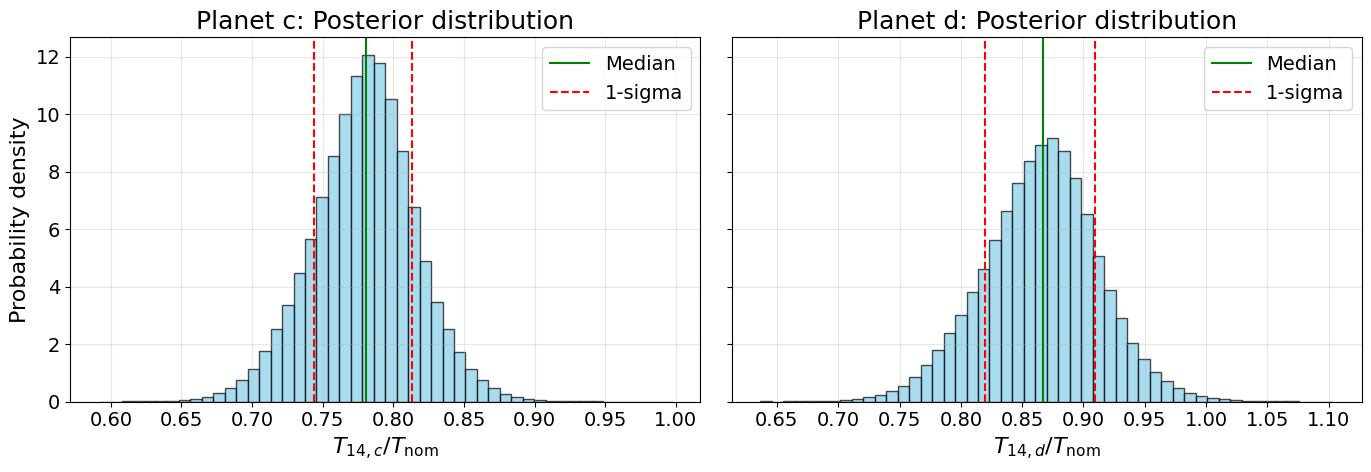

In [48]:
from matplotlib.ticker import MultipleLocator
# Bigger fonts globally
plt.rcParams.update({
    "font.size": 16,          # default text size
    "axes.titlesize": 18,     # subplot titles
    "axes.labelsize": 16,     # x and y labels
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
    "legend.fontsize": 14     # legend
})


# Quick statistics for Planet c
p16_2, p84_2 = np.percentile(T14_Tnom_2, [16, 84])
median_2 = np.median(T14_Tnom_2)
print("Planet c stats:")
print("Median:", median_2)
print("16th percentile:", p16_2)
print("84th percentile:", p84_2)

# Quick statistics for Planet d
p16_3, p84_3 = np.percentile(T14_Tnom_3, [16, 84])
median_3 = np.median(T14_Tnom_3)
print("\nPlanet d stats:")
print("Median:", median_3)
print("16th percentile:", p16_3)
print("84th percentile:", p84_3)

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Planet c ---
axes[0].hist(T14_Tnom_2, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='k')
axes[0].axvline(median_2, color='green', linestyle='-', label='Median')
axes[0].axvline(p16_2, color='red', linestyle='--', label='1-sigma')
axes[0].axvline(p84_2, color='red', linestyle='--')
axes[0].set_xlabel(r"$T_{14,c} / T_\mathrm{nom}$")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Planet c: Posterior distribution")
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[0].xaxis.set_major_locator(MultipleLocator(0.05))  # adjust tick spacing


# --- Planet d ---
axes[1].hist(T14_Tnom_3, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='k')
axes[1].axvline(median_3, color='green', linestyle='-', label='Median')
axes[1].axvline(p16_3, color='red', linestyle='--', label='1-sigma')
axes[1].axvline(p84_3, color='red', linestyle='--')
axes[1].set_xlabel(r"$T_{14,d} / T_\mathrm{nom}$")
axes[1].set_title("Planet d: Posterior distribution")
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].xaxis.set_major_locator(MultipleLocator(0.05))  # adjust tick spacing


plt.tight_layout()
plt.show()

In [42]:
print("ecc2 Median:", np.median(post_e_2))
print("ecc2 16th percentile:", np.percentile(post_e_2, 16))
print("ecc2 84th percentile:", np.percentile(post_e_2, 84))
print("ecc3 Median:", np.median(post_e_3))
print("ecc3 16th percentile:", np.percentile(post_e_3, 16))
print("ecc3 84th percentile:", np.percentile(post_e_3, 84))

ecc2 Median: 0.11931818866925742
ecc2 16th percentile: 0.02959163268292385
ecc2 84th percentile: 0.43625250238331803
ecc3 Median: 0.13229210474653386
ecc3 16th percentile: 0.03396198764797563
ecc3 84th percentile: 0.4519205349630523


In [43]:
print("jnkep ecc2 Median:", np.median(ecc_2))
print("jnkep ecc2 16th percentile:", np.percentile(ecc_2, 16))
print("jnkep ecc2 84th percentile:", np.percentile(ecc_2, 84))
print("jnkep ecc3 Median:", np.median(ecc_3))
print("jnkep ecc3 16th percentile:", np.percentile(ecc_3, 16))
print("jnkep ecc3 84th percentile:", np.percentile(ecc_3, 84))

jnkep ecc2 Median: 0.078028105
jnkep ecc2 16th percentile: 0.004199487306177615
jnkep ecc2 84th percentile: 0.20871291995048522
jnkep ecc3 Median: 0.06574204
jnkep ecc3 16th percentile: 0.003459676336497067
jnkep ecc3 84th percentile: 0.17844843327999116
